# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

## Import and Defining DF

In [1]:
# Para os dados

import pandas as pd
import numpy as np
import os

# Para a visualização

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Para o modelo

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Para Avaliação

from sklearn.metrics import silhouette_score

In [2]:
# Verificando se caminho existe:

path = '.\\Mall_Customers.csv'

if os.path.exists(path):
    print("The file has been found!!! ")
else:
    print("The file has not been found...")

# Atribuindo DF

df_original = pd.read_csv(path, delimiter=',')
df_original.head(10)

The file has been found!!! 


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## Tratando Dados

In [3]:
# Vericando se há valores nulos e se os tipos de dados estão corretos

df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


OBS: Não há valores nulos e os tipos de dados estão adequados. No entanto, a variável Gender não será utilizada neste primeiro momento. Como o K-Means trabalha com distâncias, incluir uma variável categórica binária codificada poderia introduzir ruído na formação dos grupos. Além disso, diferenças de comportamento de compra entre gêneros tendem a já estar refletidas, ao menos parcialmente, na variável Spending Score.

In [4]:
# Remoção das colunas

try:
    df = df_original.drop(['CustomerID'], axis=1)
except:
    print("Coluna (CustomerID) não foi removida")

df = df.drop(['Gender'], axis = 1)

Obs: Decidi remover a coluna Gender, pois, por possuir apenas duas categorias, ela pode não contribuir de forma relevante para a formação dos agrupamentos neste contexto. Além disso, será mais útil analisar essa variável posteriormente, já com os clusters definidos, para enriquecer o perfil de cada grupo sem interferir diretamente na clusterização.

## EDA

In [5]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Obs: A princípio, pela função describe, não há nenhum outlier, e os valores fazem sentido.

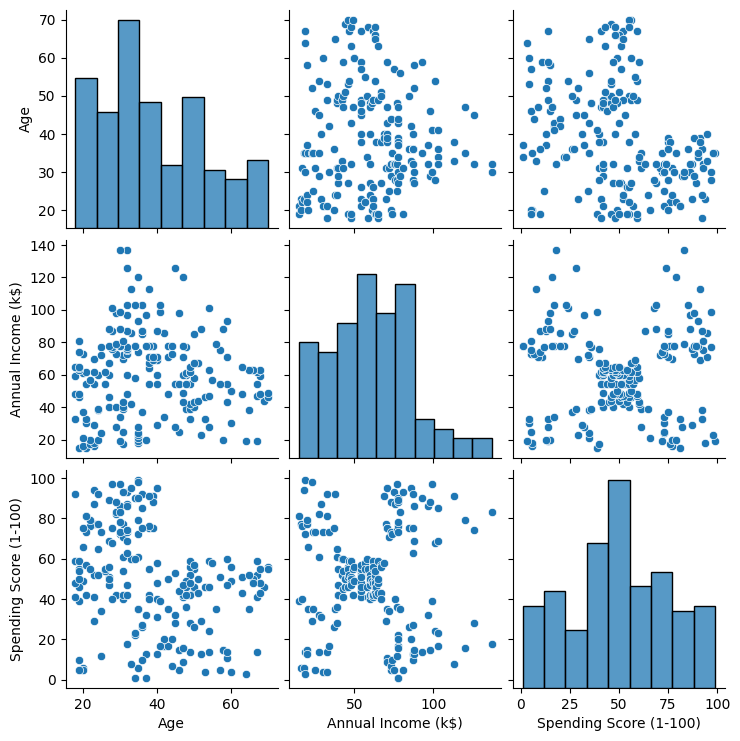

In [6]:
sns.pairplot(df)

Obs: Com base no gráfico acima, é possível perceber indícios de agrupamentos naturais nos dados. Visualmente, uma escolha entre 3 e 4 clusters parece plausível. Além disso, observa-se uma tendência interessante: clientes com mais de 40 anos raramente apresentam Spending Score acima de 60, o que pode sugerir um padrão de consumo mais contido nesse grupo. Já os clientes mais jovens parecem concentrar valores mais altos de pontuação de gasto.

## Padronização dos dados

In [7]:
# Criando váriavel de Padronização

scaler = StandardScaler()


# Criando DF a ser padronizado

df_pad = df.copy()

try:
    df_pad = df_pad.rename(columns={
            'Annual Income (k$)': 'Annual_Income',
            'Spending Score (1-100)': 'Spending_Score'
        })
except:
    print("Colunas já foram renomeadas!") 

# Definindo as colunas a serem padronizados

Coluna_pad = ['Age', 'Annual_Income', 'Spending_Score']

df_pad[Coluna_pad] = scaler.fit_transform(df_pad[Coluna_pad])

# Verificando resultado

df_pad.head(10)

,Age,Annual_Income,Spending_Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
5,-1.209269,-1.662660,1.001596
6,-0.276302,-1.624491,-1.715913
7,-1.137502,-1.624491,1.700384
8,1.804932,-1.586321,-1.832378
9,-0.635135,-1.586321,0.846310


Obs: A padronização foi realizada porque o K-Means é sensível à escala das variáveis, já que a formação dos clusters depende da distância entre os pontos. Sem padronização, variáveis com magnitude maior podem dominar o processo de agrupamento e distorcer os resultados.

# Aplicando Kmeans

In [8]:
# Criação do modelo

km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=48)

# Aplicando o modelo

km.fit(df_pad)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,48
,copy_x,True
,algorithm,'lloyd'


Obs: Em uma primeira tentativa, utilizei n_clusters = 4. No entanto, os centróides ficaram muito próximos entre si, o que dificultou a distinção entre os grupos. Ao reduzir para n_clusters = 3, os clusters se tornaram mais nítidos visualmente, facilitando a interpretação e a segmentação dos perfis. As observações sobre esse resultado serão detalhadas nos gráficos a seguir.

# Resultados

- Preparação

In [9]:
# Pegando centroides

centroides = km.cluster_centers_

# Invertendo para os dados originais

centroides_originais = scaler.inverse_transform(centroides)
print(centroides_originais)

# Criando labels

labels = km.labels_
print(labels)

# Criando df para criar gráficos para visualizar os resultados.

df_clusters = pd.DataFrame({
    'Age' : df['Age'],
    'Annual_Income' : df['Annual Income (k$)'],
    'Spending_Score' : df['Spending Score (1-100)'],
    'cluster' : labels.astype(str) 
})


[[51.27472527 61.8021978  34.20879121]
 [32.85365854 87.34146341 79.97560976]
 [25.83823529 42.75       53.64705882]]
[2 2 2 2 2 2 2 2 0 2 0 2 0 2 2 2 2 2 0 2 2 2 0 2 0 2 0 2 2 2 0 2 0 2 0 2 0
 2 2 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 2 0 0 2 0 0 2 2 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 0 2 2 2 0 0 0 0 2 0 1 1 2 1 0 1 0 1 0 1 2 1 2 1 0 1 2 1 0 1 2 1 2 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1]


- Gráfico 1 (Age x Spending Score)

In [10]:
# Plotando os pontos do gráfico

fig = px.scatter(
    df_clusters, x='Age', y='Spending_Score', 
    color='cluster',
    color_continuous_scale='viridis',
    opacity=0.8,
    title='Clusters do Spending Score em Relação a Idade do Cliente'
)

# Adicionando os centroides

fig.add_scatter(
    x=centroides_originais[:, 0], y=centroides_originais[:, 1],
    mode='markers',
    marker=dict(color='red', symbol='x', size=14),
    name="Centroides"
)

fig.update_layout(
    xaxis_title='Idade', yaxis_title='Spending Score (1-100)',
    legend_title='Cluster'
)

Obs: Com 3 clusters, já é possível visualizar perfis distintos de clientes. Nota-se que pessoas com mais de 40 anos não apresentam Spending Score elevado, o que pode indicar menor engajamento com as ofertas atuais do shopping. Esse grupo parece numeroso e, portanto, pode representar uma oportunidade estratégica. No entanto, antes de propor ações, é importante observar também a relação entre idade e renda anual, pois isso ajuda a avaliar se o menor nível de consumo está associado ao poder de compra ou a uma possível falta de atratividade das ofertas. 

- Gráfico 2 (Age x Annual Income)

In [11]:
# Plotando os pontos do gráfico

fig = px.scatter(
    df_clusters, x='Age', y='Annual_Income', 
    color='cluster',
    color_continuous_scale='viridis',
    opacity=0.8,
    title='Clusters da Renda Anual em Relação a Idade do Cliente'
)

# Adicionando os centroides

fig.add_scatter(
    x=centroides_originais[:, 0], y=centroides_originais[:, 2],
    mode='markers',
    marker=dict(color='red', symbol='x', size=14),
    name="Centroides"
)

fig.update_layout(
    xaxis_title='Idade', yaxis_title='Renda Anual (k$)',
    legend_title='Cluster'
)

Obs: A relação entre idade e renda anual sugere que o menor Spending Score de clientes acima de 40 anos não está necessariamente ligado à falta de poder aquisitivo. Isso pode indicar que o problema não é preço, mas sim aderência das experiências e ofertas disponíveis a esse público. Assim, ações mais direcionadas, como eventos, campanhas temáticas ou serviços voltados a esse perfil, podem ser uma alternativa interessante para aumentar o engajamento desse grupo.

In [13]:
# Métricas

print(f"Inércia: {km.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(df_pad, km.labels_):.4f}")

Inércia: 295.21
Silhouette Score: 0.3578


Obs: Além da análise visual, também foram usadas métricas para avaliar os clusters. A inércia foi de 295.2, representando a compactação dos grupos, mas esse valor sozinho não é suficiente para determinar a qualidade do modelo. Já o Silhouette Score foi de 0.35, indicando que os clusters possuem uma separação moderada. Assim, o agrupamento encontrado pelo K-Means pode ser considerado satisfatório, embora não apresente uma divisão perfeitamente definida entre todos os grupos.

# Conclusão

- Grupos

Com base nos clusters gerados pelo modelo, foi possível identificar três segmentos de clientes:

1. Clientes mais jovens, com renda anual mais baixa e alto Spending Score
Esse grupo mostra que o shopping consegue atrair clientes que, mesmo sem renda elevada, demonstram forte propensão ao consumo. Isso sugere boa aderência das ofertas a esse perfil.

2. Clientes entre aproximadamente 27 e 39 anos, com renda anual mais alta e Spending Score também elevado
Trata-se de um grupo bastante valioso, pois reúne capacidade de compra e forte engajamento com o shopping. Mesmo que não seja o maior grupo, possui alto potencial estratégico.

3. Clientes acima de 40 anos, com renda anual relativamente alta, mas Spending Score mais baixo
Esse grupo chama atenção porque apresenta poder aquisitivo, mas menor propensão ao consumo dentro do shopping. Isso pode indicar que as ofertas atuais não estão plenamente alinhadas aos seus interesses.

- Soluções

Para grupo 1:

Como esse grupo já apresenta Spending Score alto, a estratégia pode ser ampliar ainda mais o volume de compras por meio de promoções, combos, campanhas sazonais e benefícios de recorrência. Como a renda média não é tão alta, ações com maior percepção de custo-benefício tendem a funcionar melhor.

Para o grupo 2:

Esse é o grupo ideal e é importante manter assim, logo, programas de fidelização podem ajudar bastante para manter esse grupo como ideal.

Para grupo 3:

Esse grupo possui renda anual elevada, mas baixo Spending Score, o que sugere uma oportunidade clara de crescimento. Como o fator financeiro não parece ser a principal limitação, ações voltadas à experiência podem ser mais eficazes, como eventos culturais, conveniências, serviços diferenciados e campanhas direcionadas a esse perfil.